In [2]:
import uproot
import numpy as np
import matplotlib.pyplot as plt
import math
from scipy.interpolate import make_interp_spline
from scipy.optimize import curve_fit
import ROOT
from colorama import Fore, Style, init
init(autoreset=True)

import numpy as np

def baseline_subtract(pulse, n_baseline=16):
    """
    Subtracts baseline from a pulse.
    n_baseline: number of samples at start used to estimate baseline
    """
    baseline = np.median(pulse[:n_baseline])
    return pulse - baseline
    
def gaussian(x, amplitude, mean, sigma):
    return amplitude * np.exp(-(x - mean)**2 / (2 * sigma**2))
    
def crystalball(x, alpha, n, mean, sigma, N):
    # (N = normalization)
    z = (x - mean) / sigma
    if isinstance(z, np.ndarray):
        result = np.zeros_like(z)
    else:
        result = 0

    # Transition point
    mask = z > -alpha

    # Gaussian region
    result[mask] = N * np.exp(-0.5 * z[mask]**2)

    # Power-law tail region
    A = (n / abs(alpha))**n * np.exp(-0.5 * alpha**2)
    B = n / abs(alpha) - abs(alpha)
    result[~mask] = N * A * (B - z[~mask])**(-n)

    return result

def cb_plus_const(x, alpha, n, mu, sigma, N, C):
    return crystalball(x, alpha, n, mu, sigma, N) + C

def ReadProcessedFile(filename,treeName="treeML",paramType=True):
    file = uproot.open(filename)
    tree = file[treeName]
    treeData = tree.arrays(["t0","t1","t2","t3","q0","q1","q2","q3","samples0","samples2"],library="np")
    param_list02=[]
    param_list13=[]
    for i in range(len(treeData["q0"])):
        if paramType:
            param_list02.append((np.float64(treeData["t0"][i])-np.float64(treeData["t2"][i]))/1000.)
            param_list13.append((np.float64(treeData["t3"][i])-np.float64(treeData["t1"][i]))/1000.)
        else:
            param_list02.append(math.log(treeData["q2"][i]/treeData["q0"][i]))
            param_list13.append(math.log(treeData["q1"][i]/treeData["q3"][i]))
            '''
            pulse0=treeData["samples0"]
            pulse2=treeData["samples2"]
            for i in range(len(pulse0)):
                param_list02.append(math.log(np.min(baseline_subtract(pulse2[i]))/np.min(baseline_subtract(pulse0[i]))))
                #param_list13.append(math.log(np.min(baseline_subtract(pulse3[i]))/np.min(baseline_subtract(pulse1[i]))))
            '''
            
        '''
        if paramType == 0:
            param_list02.append(treeData["t0"][i]-treeData["t2"][i])
            param_list13.append(treeData["t1"][i]-treeData["t3"][i])
        elif paramType == 1:
            param_list02.append(math.log(treeData["q2"][i]/treeData["q0"][i]))
            param_list13.append(math.log(treeData["q1"][i]/treeData["q3"][i]))
        elif paramType == 2:
            pulse0=treeData["samples0"]
            pulse2=treeData["samples2"]
            for i in range(len(pulse0)):
                param_list02.append(math.log(np.min(baseline_subtract(pulse2[i]))/np.min(baseline_subtract(pulse0[i]))))
                #param_list13.append(math.log(np.min(baseline_subtract(pulse3[i]))/np.min(baseline_subtract(pulse1[i]))))
        '''
            
        
    return param_list02,param_list13

def MakeHistogramAndFit(param_list,index=0):
    binss=np.linspace(-2,2,100)
    #counts, bins, _ =plt.hist(param_list,bins=binss,histtype='step',color='blue
    plt.figure()
    counts, bins, _ =plt.hist(param_list,bins=100,histtype='step',color='blue')
    plt.close()
    bin_centers = 0.5 * (bins[1:] + bins[:-1])
    # Initial guess for fit parameters: A, mean, sigma
    p0 = [max(counts), np.mean(param_list), np.std(param_list)]
    # Fit using curve_fit
    popt, pcov = curve_fit(gaussian, bin_centers, counts, p0=p0)
    # Extract fit results
    A_fit, mu_fit, sigma_fit = popt
    #print(f"Fit results for file at Position={index}, A={A_fit:.2f}, mu={mu_fit:.2f}, sigma={sigma_fit:.2f}")
    return popt,bins

def PlotFit(dist,popt,bins):
    x_fit = np.linspace(min(bins), max(bins), 1000)
    y_fit = dist(x_fit, *popt)
    plt.plot(x_fit, y_fit, 'r--', linewidth=2, label='Gaussian Fit')

def FitPolynomial(listx,listy,color="b"):
    linetype=color+"--"
    plt.plot(listx,listy,"o",color='red')
    #print(listx)
    coeffs = np.polyfit(listx, listy, 3)  # degree = 3
    poly = np.poly1d(coeffs)
    x_fit = np.linspace(min(listx), max(listx), 500)
    y_fit = poly(x_fit)
    plt.plot(x_fit, y_fit, linetype, label="3rd Order Fit")
    return poly


    


Welcome to JupyROOT 6.30/04


25
25
25
(25,)
deg=1: R2_x mean=0.000, R2_y mean=0.882
deg=2: R2_x mean=0.000, R2_y mean=0.870
deg=3: R2_x mean=0.000, R2_y mean=0.832
predicted (x,y): (np.float64(12.209050466763202), np.float64(0.5853941619463814))


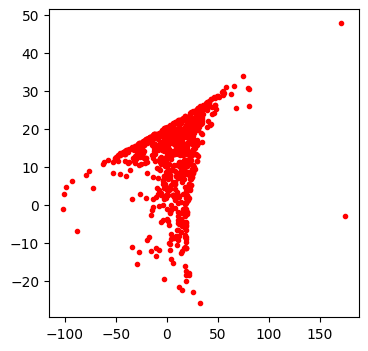

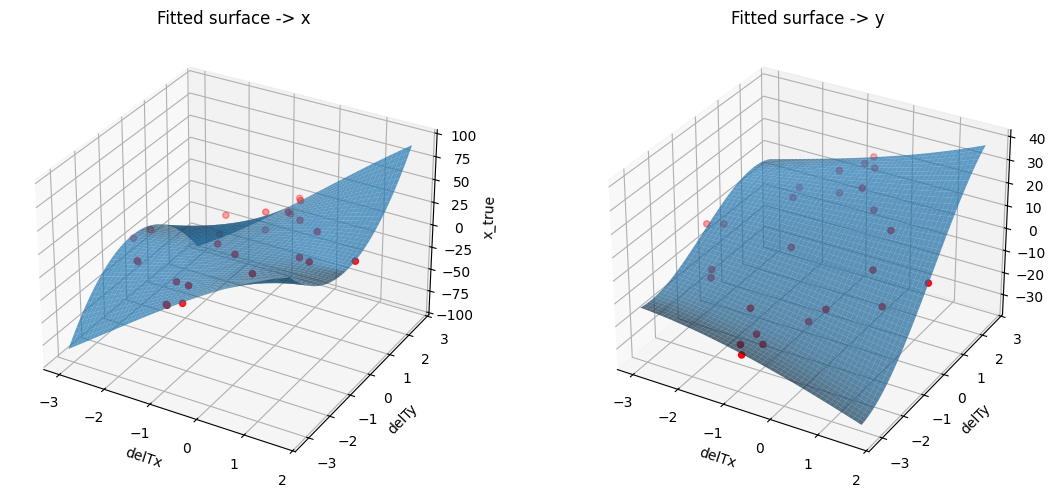

In [9]:

import numpy as np
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # registers 3D

from sklearn.linear_model import LinearRegression
paramType=True
base_path="/home/rsehgal/shared/SquareScint/CPP/build/"
#file_list=["Muon_output_0_-20.root","Muon_output_0_-15.root","Muon_output_0_-10.root","Muon_output_0_-5.root","Muon_output_0_0.root","Muon_output_0_5.root","Muon_output_0_10.root","Muon_output_0_15.root","Muon_output_0_20.root"]
list_Of_Xfile_list=[]
list_Of_Yfile_list=[]
#loc_list = [-20,-15,-10,-5,0,5,10,15,20]
loc_list = [-20,-10,0,10,20]
X_phys = []
Y_phys = []
file_list=[]
for i in loc_list:
    for j in loc_list:
        X_phys.append(i)
        Y_phys.append(j)
        file_list.append("Muon_output_"+str(i)+"_"+str(j)+".root")
print(len(file_list))
mean_list02=[]
mean_list13=[]
paramType=True
for index in range(len(file_list)):
    param_list02,param_list13 = ReadProcessedFile(base_path+file_list[index],paramType=paramType)
    
    popt,bins=MakeHistogramAndFit(param_list02,index)
    A_fit, mu_fit, sigma_fit = popt
    mean_list02.append(mu_fit)

    popt,bins=MakeHistogramAndFit(param_list13,index)
    A_fit, mu_fit, sigma_fit = popt
    mean_list13.append(mu_fit)

print(len(mean_list02))
print(len(mean_list13))
# === Replace these with your 25 calibration points ===
# Example placeholders (length 25)
delTx = np.array(mean_list13) # ([/* 25 values */])
delTy = np.array(mean_list02) # ([/* 25 values */])
x_true = np.array(X_phys) # ([/* 25 true x positions */])
y_true = np.array(Y_phys) # ([/* 25 true y positions */])

print(delTx.shape)

# Prepare feature matrix
X = np.vstack([delTx, delTy]).T

# Try degrees and compare with CV
for deg in (1, 2, 3):
    poly = PolynomialFeatures(degree=deg, include_bias=True)
    Xp = poly.fit_transform(X)
    model_x = LinearRegression().fit(Xp, x_true)
    model_y = LinearRegression().fit(Xp, y_true)
    # simple cv score on x and y
    scores_x = cross_val_score(LinearRegression(), Xp, x_true, cv=5, scoring='r2')
    scores_y = cross_val_score(LinearRegression(), Xp, y_true, cv=5, scoring='r2')
    print(f"deg={deg}: R2_x mean={scores_x.mean():.3f}, R2_y mean={scores_y.mean():.3f}")

# Pick a degree (say deg=2)
deg = 3
poly = PolynomialFeatures(degree=deg, include_bias=True)
Xp = poly.fit_transform(X)
model_x = LinearRegression().fit(Xp, x_true)
model_y = LinearRegression().fit(Xp, y_true)

# Function to predict position from new (delTx, delTy)
def predict_position(dtx, dty):
    v = np.array([[dtx, dty]])
    vp = poly.transform(v)
    x_pred = model_x.predict(vp)[0]
    y_pred = model_y.predict(vp)[0]
    return x_pred, y_pred

# Example predict
dtx_sample, dty_sample = 0.123, -0.045
print("predicted (x,y):", predict_position(dtx_sample, dty_sample))

testfile="Muon_output_10_15.root"
param_list13,param_list02 = ReadProcessedFile(base_path+testfile,paramType=paramType)
predX_list=[]
predY_list=[]
for index in range(len(param_list02)):
    predX,predY=predict_position(param_list02[index], param_list13[index])
    predX_list.append(predX)
    predY_list.append(predY)
    
plt.figure(figsize=(4,4))
plt.plot(predX_list,predY_list,".",color='red')

# --- Optional: plot fitted surface for x (and similarly for y) ---
# create a grid
grid_n = 50
dtx_lin = np.linspace(delTx.min(), delTx.max(), grid_n)
dty_lin = np.linspace(delTy.min(), delTy.max(), grid_n)
D1, D2 = np.meshgrid(dtx_lin, dty_lin)
grid_pts = np.vstack([D1.ravel(), D2.ravel()]).T
grid_p = poly.transform(grid_pts)
X_surf = model_x.predict(grid_p).reshape(D1.shape)
Y_surf = model_y.predict(grid_p).reshape(D1.shape)

fig = plt.figure(figsize=(12,5))
ax = fig.add_subplot(121, projection='3d')
ax.plot_surface(D1, D2, X_surf, alpha=0.7)
ax.scatter(delTx, delTy, x_true, color='r')
ax.set_xlabel('delTx'); ax.set_ylabel('delTy'); ax.set_zlabel('x_true'); ax.set_title('Fitted surface -> x')

ax2 = fig.add_subplot(122, projection='3d')
ax2.plot_surface(D1, D2, Y_surf, alpha=0.7)
ax2.scatter(delTx, delTy, y_true, color='r')
ax2.set_xlabel('delTx'); ax2.set_ylabel('delTy'); ax2.set_zlabel('y_true'); ax2.set_title('Fitted surface -> y')

plt.tight_layout()
plt.show()
